In [ ]:
# SESSION VARIABLES

# LOCATION
"""
LOCATIONS:
    - /gdrive/My Drive/Dataset/test/stone-canyon_20170701_20240318
    - /gdrive/My Drive/Dataset/test/the-line_west_20230101_20231231
    - /gdrive/My Drive/Dataset/test/key-west_20170701_20240319
    - /gdrive/My Drive/Dataset/test/nazare_20161201_20240311
    - /gdrive/My Drive/Dataset/test/lahaina_20230101_20240327
    - /gdrive/My Drive/Dataset/test/sj_20170701_20240329
    - /gdrive/My Drive/Dataset/test/pyongyang_20230101_20231231
    - /gdrive/My Drive/Dataset/test/gwadar_10m_20230101_20231231
    - /gdrive/My Drive/Dataset/test/hershey_20230101_20231231
    - /gdrive/My Drive/Dataset/test/intel_20170701_20240315
    - /gdrive/My Drive/Dataset/test/the-line_east_20230101_20231231
    - /gdrive/My Drive/Dataset/test/obx_20230101_20231231
    - /gdrive/My Drive/Dataset/test/manhattan_20170701_20240402
    - /gdrive/My Drive/Dataset/test/samples
"""
directory = '/gdrive/My Drive/Dataset/test/obx_20230101_20231231'

# MODEL
model_name = 'unet_vgg_14'

# GIF
filename = 'obx_vgg14.gif'
threshold = 0.7 # probability threshold to be applied to the gif prediction maps
duration = 10.0  # Duration of each frame in seconds

# PREDICTION MAP
instance_threshold = 3  # Minimum number of images
probability_threshold = 0.7  # Prediction probability threshold

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

import os
import time
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
import tensorflow as tf
import matplotlib.pyplot as plt
import imageio

start_execution_time = time.time()

Mounted at /gdrive


In [ ]:
def visualize_predictions(images, masks, thresholded_visualization=False, threshold=0.95):
    """
    Visualize a list of images with their corresponding prediction masks and overlay.

    Parameters:
    - images: List of original images.
    - masks: List of predicted masks corresponding to the images.
    - thresholded_visualization: Boolean to toggle between binarized and grayscale (un-thresholded) visualization.
    - threshold: Threshold value for binarizing the masks.
    """
    num_images = len(images)
    fig, axs = plt.subplots(num_images, 3, figsize=(15, num_images * 5))  # Adjust size as needed

    for i in range(num_images):
        # Display original image
        axs[i, 0].imshow(images[i])
        axs[i, 0].title.set_text(f'Original Image {i+1}')
        axs[i, 0].axis('off')

        # Display prediction mask
        if thresholded_visualization:
            # Binarize mask
            binarized_mask = (masks[i] > threshold).astype(np.uint8)
            axs[i, 1].imshow(binarized_mask, cmap='gray')
        else:
            # Display as grayscale
            axs[i, 1].imshow(masks[i], cmap='gray')

        axs[i, 1].title.set_text(f'Prediction Mask {i+1}')
        axs[i, 1].axis('off')

        # Create overlay image
        overlay = images[i].copy()
        # Ensure overlay is RGB
        if overlay.shape[2] != 3:
            overlay = np.stack([overlay]*3, axis=-1)
        # Apply mask
        mask = (masks[i] > threshold)
        overlay[mask] = [255, 165, 0]  # High-contrast orange

        # Display overlay image
        axs[i, 2].imshow(overlay)
        axs[i, 2].title.set_text(f'Overlay {i+1}')
        axs[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

def load_images_from_directory(directory):
    images = []
    for filename in os.listdir(directory):
        if filename.endswith(".jpg"):  # Adjust the file type if necessary
            img = Image.open(os.path.join(directory, filename))
            img = np.array(img) / 255.0
            images.append(img)
    return images

def image_to_patches(image, patch_size=256, overlap=32):
    patches = []
    step = patch_size - overlap
    x_max = image.shape[0] - patch_size
    y_max = image.shape[1] - patch_size

    for x in range(0, x_max + 1, step):
        for y in range(0, y_max + 1, step):
            patch = image[x:x + patch_size, y:y + patch_size]
            patches.append(patch)

    # Edge patches (right and bottom)
    if x_max % step != 0:
        for y in range(0, y_max + 1, step):
            patch = image[x_max:x_max + patch_size, y:y + patch_size]
            patches.append(patch)
    if y_max % step != 0:
        for x in range(0, x_max + 1, step):
            patch = image[x:x + patch_size, y_max:y_max + patch_size]
            patches.append(patch)
    if x_max % step != 0 or y_max % step != 0:
        patch = image[x_max:x_max + patch_size, y_max:y_max + patch_size]
        patches.append(patch)

    return patches

def predict_patches(model, patches):
    predictions = []
    pred_count = 0
    patch_count = len(patches)
    for patch in patches:
        patch = np.expand_dims(patch, axis=0)  # Add batch dimension
        prediction = model.predict(patch, verbose=0)
        predictions.append(prediction.squeeze())  # Remove batch dimension
        pred_count += 1
    return predictions

import math

def reassemble_patches(patches, original_shape, patch_size=256, overlap=32):
    step = patch_size - overlap
    image_height, image_width = original_shape[:2]
    reassembled_image = np.zeros(original_shape[:2])

    # Create an accumulator image to count the number of predictions per pixel
    count = np.zeros(original_shape[:2])

    expected_patches_x = math.ceil((image_height - patch_size) / step) + 1
    expected_patches_y = math.ceil((image_width - patch_size) / step) + 1
    total_expected_patches = expected_patches_x * expected_patches_y
    #print("Expected patches:", total_expected_patches, "Actual patches:", len(patches))

    if len(patches) != total_expected_patches:
        raise ValueError("Mismatch between expected and actual number of patches")

    patch_idx = 0
    for x in range(0, image_height - patch_size + 1, step):
        for y in range(0, image_width - patch_size + 1, step):
            x_end = min(x + patch_size, image_height)
            y_end = min(y + patch_size, image_width)
            patch_x_end = patch_size if x + patch_size <= image_height else image_height - x
            patch_y_end = patch_size if y + patch_size <= image_width else image_width - y

            reassembled_image[x:x_end, y:y_end] += patches[patch_idx][:patch_x_end, :patch_y_end]
            count[x:x_end, y:y_end] += 1
            patch_idx += 1

    # Avoid division by zero
    count[count == 0] = 1
    reassembled_image /= count  # Normalize the accumulated predictions

    return reassembled_image


# Metric functions
def dice_coefficient(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + epsilon()) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + epsilon())

def jaccard_index(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f + y_pred_f) - intersection
    return (intersection + epsilon()) / (union + epsilon())

def sensitivity(y_true, y_pred):
    true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    possible_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true, 0, 1)))
    return true_positives / (possible_positives + epsilon())

def specificity(y_true, y_pred):
    true_negatives = tf.reduce_sum(tf.round(tf.clip_by_value((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = tf.reduce_sum(tf.round(tf.clip_by_value(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + epsilon())

def precision(y_true, y_pred):
    true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    predicted_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_pred, 0, 1)))
    return true_positives / (predicted_positives + epsilon())

# LOSS
def weighted_binary_crossentropy(weights):
    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weighted_bce = bce * (weights[1] * y_true + weights[0] * (1 - y_true))
        return tf.keras.backend.mean(weighted_bce)
    return loss

weighted_loss = weighted_binary_crossentropy([0.5355597809300489, 7.530414514976497])

# handles gif creation
def ensure_directory_exists(directory):
    """Ensure the directory exists, and if not, create it."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def create_gif(images, masks, save_path, filename='result.gif', duration=5.0, threshold=0.5, dpi=100):
    """
    Create a GIF from a list of images and their corresponding prediction masks,
    applying a threshold to the prediction masks and eliminating all white space.

    Parameters:
    - images: List of original images.
    - masks: List of predicted masks corresponding to the images.
    - save_path: Directory to save the GIF.
    - filename: Name of the GIF file.
    - duration: Display duration of each frame in the GIF in seconds.
    - threshold: Threshold value to apply to prediction masks.
    - dpi: Dots per inch for controlling image resolution.
    """
    # Ensure the output directory exists
    ensure_directory_exists(save_path)

    # Specify the full path
    full_path = f'{save_path}/{filename}'

    # Using `format='GIF'` and `loop=0` to explicitly set the format and make it loop indefinitely
    with imageio.get_writer(full_path, mode='I', duration=duration, format='GIF', loop=0) as writer:
        for img, mask in zip(images, masks):
            # Apply threshold to mask
            mask = np.where(mask > threshold, mask, 0)

            # Create a figure to hold the images with no extra space
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(img.shape[1] / dpi, 2 * img.shape[0] / dpi), dpi=dpi)
            ax1.imshow(img)  # Show original image
            ax1.axis('off')
            ax2.imshow(mask, cmap='gray')  # Show prediction mask
            ax2.axis('off')
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)  # Remove any spacing between images

            # Save the plot to a numpy array
            fig.canvas.draw()
            image_array = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
            image_array = image_array.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            writer.append_data(image_array)
            plt.close(fig)

    print(f"GIF saved to {full_path}")

Loading images...
Loaded 12 images.
Loading model...
Model unet_vgg_14 loaded.
Beginning prediction on 12 images...



Predicting on 12 images:   0%|          | 0/12 [00:00<?, ?image/s]

Predicting on 72 patches for image 1:   0%|          | 0/72 [00:00<?, ?patch/s]

Predicting on 72 patches for image 2:   0%|          | 0/72 [00:00<?, ?patch/s]

Predicting on 72 patches for image 3:   0%|          | 0/72 [00:00<?, ?patch/s]

...

Predicting on 72 patches for image 9:   0%|          | 0/72 [00:00<?, ?patch/s]

Predicting on 72 patches for image 10:   0%|          | 0/72 [00:00<?, ?patch/s]

Predicting on 72 patches for image 11:   0%|          | 0/72 [00:00<?, ?patch/s]

Predicting on 72 patches for image 12:   0%|          | 0/72 [00:00<?, ?patch/s]

Prediction completed for all images.

Prediction completed in 55.60 seconds.


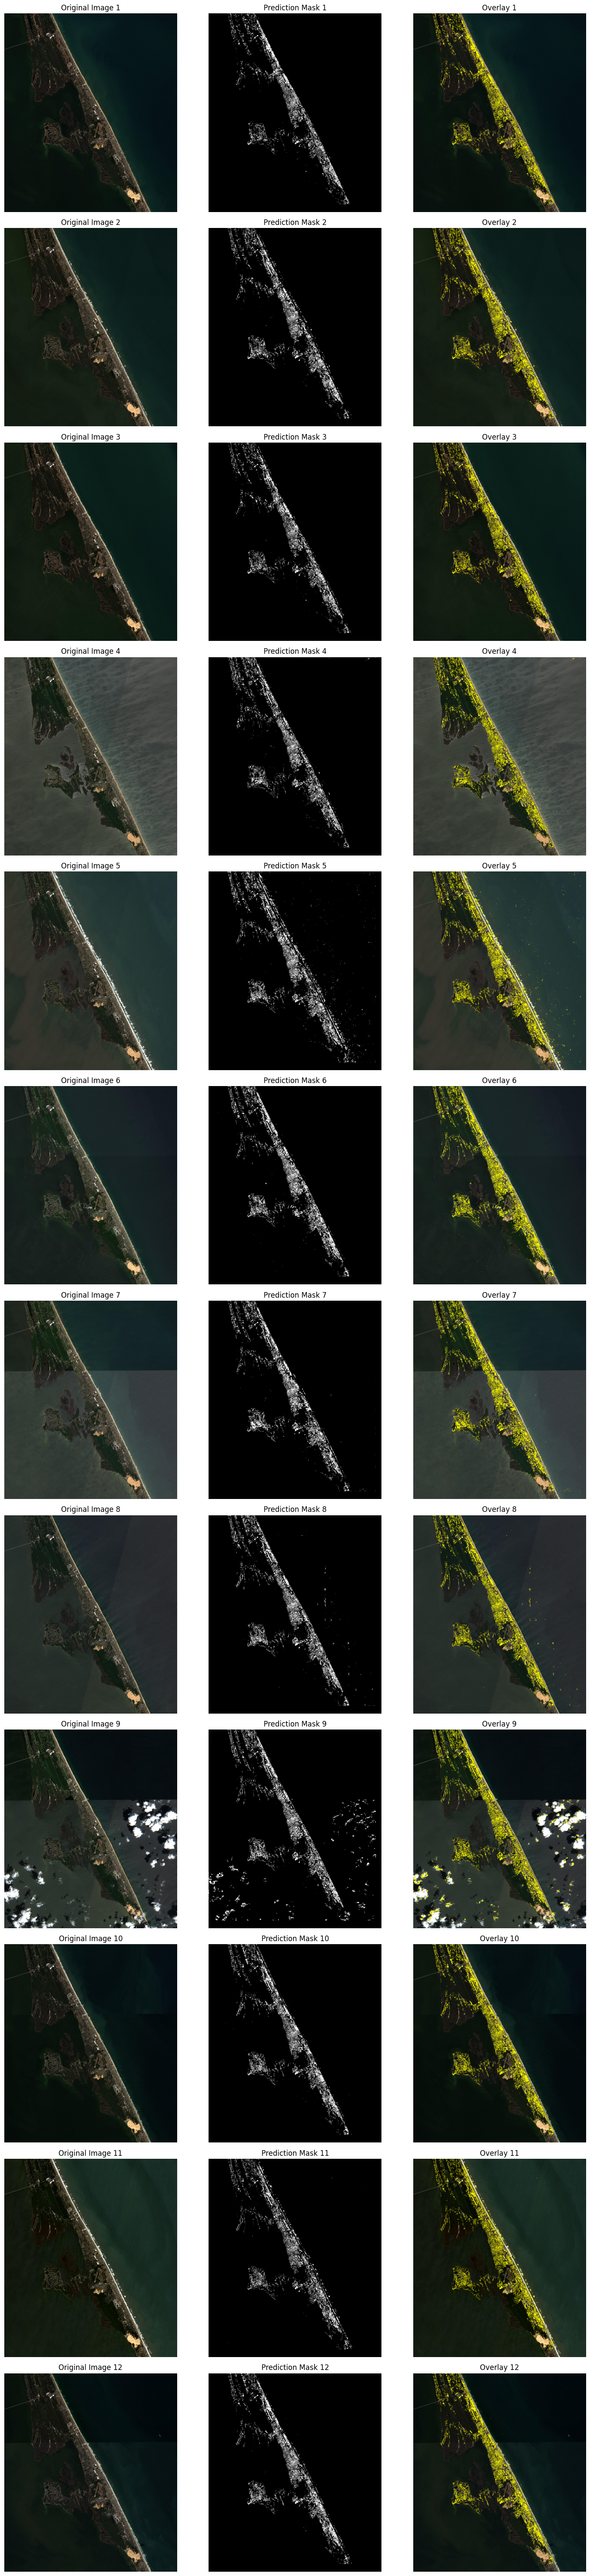

In [ ]:
from tqdm.notebook import tqdm  # Use notebook version of tqdm for better compatibility with Colab

# Load the imagery
print('Loading images...')
images = load_images_from_directory(directory)
print(f'Loaded {len(images)} images.')

# Load the model
model_save_path = f'/gdrive/My Drive/Dataset/Models/{model_name}.keras'
print('Loading model...')
model = load_model(model_save_path, custom_objects={'dice_coefficient': dice_coefficient, 'jaccard_index': jaccard_index, 'precision': precision, 'specificity': specificity, 'sensitivity': sensitivity, 'loss': weighted_loss})
print(f'Model {model_name} loaded.')

# Predict
full_masks = []
print(f"Beginning prediction on {len(images)} images...\n")
prediction_start_time = time.time()
for count, image in enumerate(tqdm(images, desc=f'Predicting on {len(images)} images', unit='image'), 1):
    patches = image_to_patches(image)
    predictions = []

    with tqdm(total=len(patches), desc=f'Predicting on {len(patches)} patches for image {count}', unit='patch', leave=False) as pbar:
        for i, patch in enumerate(patches):
            prediction = predict_patches(model, [patch])
            predictions.append(prediction[0])
            pbar.update(1)

    full_mask = reassemble_patches(predictions, image.shape)
    full_masks.append(full_mask)
prediction_end_time = time.time()
print("Prediction completed for all images.")
print(f"\nPrediction completed in {prediction_end_time - prediction_start_time:.2f} seconds.")

# Visualize predictions
visualize_predictions(images, full_masks, thresholded_visualization=True, threshold=threshold)